<a href="https://colab.research.google.com/github/poojya100/6thSem-ML-Lab/blob/main/1BM23CS303_Lab_6_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iris dataset

With Library

In [2]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("iris (1).csv")

# Features and target
X = data.drop("species", axis=1)
y = data["species"]

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create KNN model (k=5)
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Without Library

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load dataset
data = pd.read_csv("iris (1).csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

k = 5

# Euclidean distance
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# KNN prediction
def predict(x):
    distances = []

    for i in range(len(X_train)):
        d = euclidean_distance(x, X_train[i])
        distances.append((d, y_train[i]))

    distances.sort(key=lambda x: x[0])

    neighbors = distances[:k]

    classes = [neighbor[1] for neighbor in neighbors]

    return max(set(classes), key=classes.count)

# Predictions
predictions = []

for x in X_test:
    predictions.append(predict(x))

# Accuracy
accuracy = np.sum(predictions == y_test) / len(y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


Diabetes dataset

With Library

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("diabetes (1).csv")

# Features and target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6883116883116883
Confusion Matrix:
 [[79 20]
 [28 27]]


Without Library

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv("diabetes (1).csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

k = 5

# Euclidean distance
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# Prediction function
def predict(x):
    distances = []

    for i in range(len(X_train)):
        d = euclidean_distance(x, X_train[i])
        distances.append((d, y_train[i]))

    distances.sort(key=lambda x: x[0])

    neighbors = distances[:k]

    classes = [neighbor[1] for neighbor in neighbors]

    return max(set(classes), key=classes.count)

# Predict test data
predictions = []

for x in X_test:
    predictions.append(predict(x))

# Accuracy
accuracy = np.sum(predictions == y_test) / len(y_test)

print("Accuracy:", accuracy)

Accuracy: 0.7272727272727273


Heart dataset

With Library

Best K value: 6
Accuracy: 0.9344262295081968
Confusion Matrix:
 [[28  1]
 [ 3 29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93        29
           1       0.97      0.91      0.94        32

    accuracy                           0.93        61
   macro avg       0.93      0.94      0.93        61
weighted avg       0.94      0.93      0.93        61



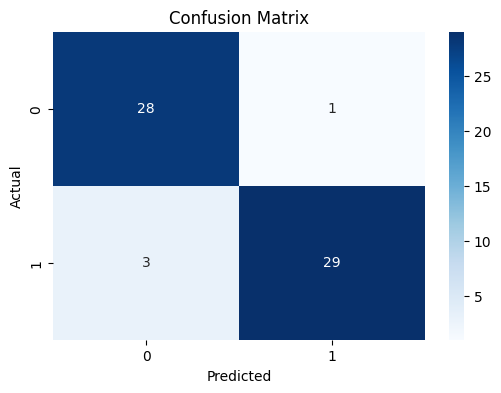

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("heart.csv")

# Features and target
X = data.drop("target", axis=1)
y = data["target"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Find best K value
scores = []

for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test,y_pred))

best_k = scores.index(max(scores)) + 1
print("Best K value:", best_k)

# Train final model
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train,y_train)

# Prediction
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:",accuracy_score(y_test,y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

# Classification Report
print("Classification Report:\n",classification_report(y_test,y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,cmap="Blues",fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Without Library

Accuracy: 0.819672131147541
Confusion Matrix:
 [[22.  9.]
 [ 2. 28.]]


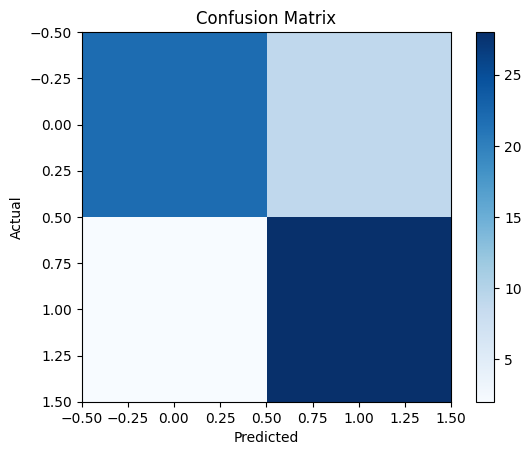

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter

# Load dataset
data = pd.read_csv("heart.csv")

X = data.iloc[:,:-1].values
y = data.iloc[:,-1].values

# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

k = 5

# Euclidean distance
def euclidean_distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

# KNN prediction
def predict(x):
    distances = []

    for i in range(len(X_train)):
        d = euclidean_distance(x,X_train[i])
        distances.append((d,y_train[i]))

    distances.sort(key=lambda x:x[0])

    neighbors = distances[:k]

    labels = [neighbor[1] for neighbor in neighbors]

    return Counter(labels).most_common(1)[0][0]

# Predict test data
predictions = []

for x in X_test:
    predictions.append(predict(x))

predictions = np.array(predictions)

# Accuracy
accuracy = np.sum(predictions == y_test)/len(y_test)
print("Accuracy:",accuracy)

# Confusion Matrix (manual)
cm = np.zeros((2,2))

for i in range(len(y_test)):
    cm[int(y_test[i])][int(predictions[i])] += 1

print("Confusion Matrix:\n",cm)

# Plot confusion matrix
plt.imshow(cm,cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()